# Feature Engineering - BoardGames Dataset

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [2]:
df = pd.read_csv("../data/processed/boardgames_clean.csv")

In [3]:
df.shape

(22251, 417)

In [4]:
df.head()

,id,name,average_rating,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,minage,...,mech_victory,mech_voting,mech_wagers,mech_war,mech_with,mech_worker,mech_workers,mech_you,mech_your,mech_zone
0,224517,Brass: Birmingham,8.57,2018,2,4,120,60,120,14,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,342942,Ark Nova,8.54,2021,1,4,150,90,150,14,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,161936,Pandemic Legacy: Season 1,8.50,2015,2,4,60,60,60,13,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,174430,Gloomhaven,8.54,2017,1,4,120,60,120,14,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,316554,Dune: Imperium,8.41,2020,1,4,120,60,120,14,...,0.0,0.0,0.0,0.0,0.0,0.128495,0.0,0.0,0.0,0.0


In [5]:
print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'playingtime', 'minplaytime', 'maxplaytime', 'minage', 'averageweight', 'users_rated', 'owned', 'wishing', 'rank', 'cat_abstract', 'cat_action', 'cat_adult', 'cat_adventure', 'cat_age', 'cat_agents', 'cat_american', 'cat_ancient', 'cat_and', 'cat_animals', 'cat_arabian', 'cat_aviation', 'cat_base', 'cat_based', 'cat_bluffing', 'cat_book', 'cat_building', 'cat_card', 'cat_children', 'cat_city', 'cat_civil', 'cat_civilization', 'cat_collectible', 'cat_comic', 'cat_components', 'cat_deduction', 'cat_dexterity', 'cat_dice', 'cat_economic', 'cat_educational', 'cat_electronic', 'cat_environmental', 'cat_expansion', 'cat_exploration', 'cat_fan', 'cat_fantasy', 'cat_farming', 'cat_fiction', 'cat_fighting', 'cat_flight', 'cat_for', 'cat_game', 'cat_horror', 'cat_humor', 'cat_ii', 'cat_indian', 'cat_industry', 'cat_korean', 'cat_mafia', 'cat_manufacturing', 'cat_math', 'cat_mature', 'cat_maze', 'cat_med

## Preparing the dataset

Although the dataset was cleaned and functional, not all the rows have values that we can use, neither we are going to use all the columns

In [6]:
#Check how many rows with 0 are in averageweight and minage columns. 
(df.iloc[:,9:11]==0).sum().sum()

np.int64(1141)

In [7]:
# 0 is not a valid result in those columns. We are going to replace them with the median
# First we change them to NaN in order to use fillna to use the median

df["averageweight"] = df["averageweight"].replace(0, np.nan)
df["minage"] = df["minage"].replace(0, np.nan)

df["averageweight"] = df["averageweight"].fillna(df["averageweight"].median())
df["minage"] = df["minage"].fillna(df["minage"].median())

### Logaritmic transformation

Check if it's needed

In [8]:
print(df["users_rated"].skew())
print(df["owned"].skew())
print(df["wishing"].skew())

11.980863085590093
12.16709686557988
9.280722110371963


<Axes: xlabel='users_rated', ylabel='Count'>

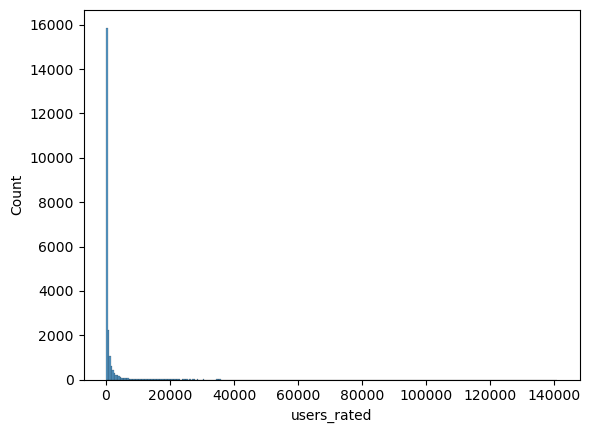

In [9]:
sns.histplot(df["users_rated"])

High skewness means we can apply the logaritmic transformation

In [10]:
new_cols = pd.DataFrame({
    "log_users_rated": np.log1p(df["users_rated"]),
    "log_owned": np.log1p(df["owned"]),
    "log_wishing": np.log1p(df["wishing"])
}, index=df.index)

df = pd.concat([df, new_cols], axis=1)

In [11]:
df = df.drop(columns=["users_rated", "owned", "wishing"])
print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'playingtime', 'minplaytime', 'maxplaytime', 'minage', 'averageweight', 'rank', 'cat_abstract', 'cat_action', 'cat_adult', 'cat_adventure', 'cat_age', 'cat_agents', 'cat_american', 'cat_ancient', 'cat_and', 'cat_animals', 'cat_arabian', 'cat_aviation', 'cat_base', 'cat_based', 'cat_bluffing', 'cat_book', 'cat_building', 'cat_card', 'cat_children', 'cat_city', 'cat_civil', 'cat_civilization', 'cat_collectible', 'cat_comic', 'cat_components', 'cat_deduction', 'cat_dexterity', 'cat_dice', 'cat_economic', 'cat_educational', 'cat_electronic', 'cat_environmental', 'cat_expansion', 'cat_exploration', 'cat_fan', 'cat_fantasy', 'cat_farming', 'cat_fiction', 'cat_fighting', 'cat_flight', 'cat_for', 'cat_game', 'cat_horror', 'cat_humor', 'cat_ii', 'cat_indian', 'cat_industry', 'cat_korean', 'cat_mafia', 'cat_manufacturing', 'cat_math', 'cat_mature', 'cat_maze', 'cat_medical', 'cat_medieval', 'cat_memory'

### New features

We will combine certain columns to have the information more compacted

In [12]:
new_cols2 = pd.DataFrame({"playtime_mean": (df["minplaytime"] + df["maxplaytime"]) / 2}, index=df.index)

df = pd.concat([df, new_cols2], axis=1)

In [13]:
df = df.drop(columns=["minplaytime", "maxplaytime", "playingtime"])         # in the correlation matrix we saw that maxplaytime == playingtime
print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'minage', 'averageweight', 'rank', 'cat_abstract', 'cat_action', 'cat_adult', 'cat_adventure', 'cat_age', 'cat_agents', 'cat_american', 'cat_ancient', 'cat_and', 'cat_animals', 'cat_arabian', 'cat_aviation', 'cat_base', 'cat_based', 'cat_bluffing', 'cat_book', 'cat_building', 'cat_card', 'cat_children', 'cat_city', 'cat_civil', 'cat_civilization', 'cat_collectible', 'cat_comic', 'cat_components', 'cat_deduction', 'cat_dexterity', 'cat_dice', 'cat_economic', 'cat_educational', 'cat_electronic', 'cat_environmental', 'cat_expansion', 'cat_exploration', 'cat_fan', 'cat_fantasy', 'cat_farming', 'cat_fiction', 'cat_fighting', 'cat_flight', 'cat_for', 'cat_game', 'cat_horror', 'cat_humor', 'cat_ii', 'cat_indian', 'cat_industry', 'cat_korean', 'cat_mafia', 'cat_manufacturing', 'cat_math', 'cat_mature', 'cat_maze', 'cat_medical', 'cat_medieval', 'cat_memory', 'cat_miniatures', 'cat_modern', 'cat_movies

## Categories

Manage all the columns of the categories

In [14]:
cat_cols = [c for c in df.columns if c.startswith("cat_")]
mech_cols = [c for c in df.columns if c.startswith("mech_")]

#### We will use PCA and KMeans to create some "type" of games

#### PCA (Principal Component Analysis) 

uses linear algebra to transform data into new features called principal components. It finds these by calculating eigenvectors (directions) and eigenvalues (importance) from the covariance matrix. PCA selects the top components with the highest eigenvalues and projects the data onto them simplify the dataset.

*from: https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/*

#### Categories

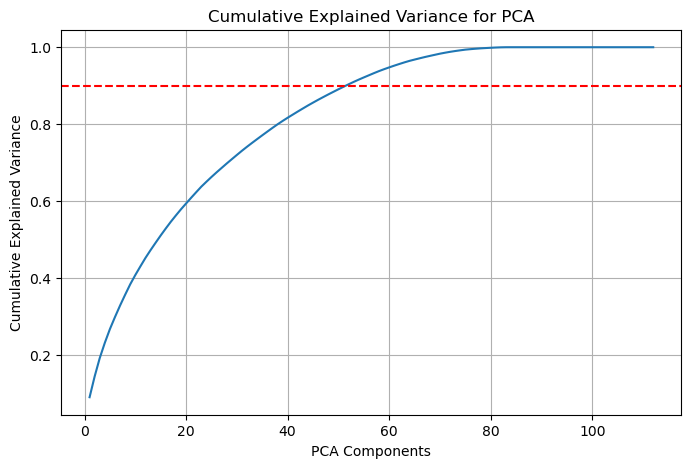

Optimal number of PCA components: 52


In [15]:
# Determine optimal number of PCA components (Cumulative Explained Variance)
pca_cat_full = PCA().fit(df[cat_cols])
explained_cat = np.cumsum(pca_cat_full.explained_variance_ratio_)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_cat) + 1), explained_cat)
plt.xlabel("PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance for PCA")
plt.axhline(y=0.90, color='r', linestyle='--')
plt.grid()
plt.show()

# Select n_components where 90% variance is retained
n_cat = np.argmax(explained_cat >= 0.90) + 1
print(f"Optimal number of PCA components: {n_cat}")

In [16]:
# Apply PCA with optimal components
pca_cat = PCA(n_components=n_cat, random_state=42)
cat_pca = pca_cat.fit_transform(df[cat_cols])

In [17]:
cat_pca_df = pd.DataFrame(cat_pca,columns=[f"pca_cat_{i}" for i in range(n_cat)],index=df.index)

#### Mechanics

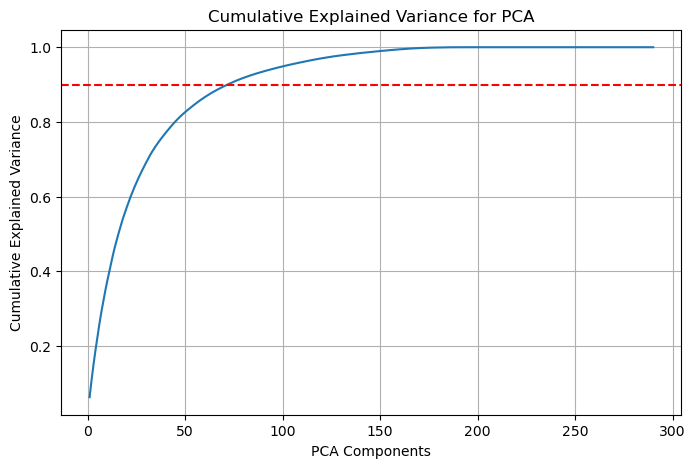

Optimal number of PCA components: 72


In [18]:
# Determine optimal number of PCA components (Cumulative Explained Variance)
pca_mech_full = PCA().fit(df[mech_cols])
explained_mech = np.cumsum(pca_mech_full.explained_variance_ratio_)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_mech) + 1), explained_mech)
plt.xlabel("PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance for PCA")
plt.axhline(y=0.90, color='r', linestyle='--')
plt.grid()
plt.show()

# Select n_components where 90% variance is retained
n_mech = np.argmax(explained_mech >= 0.90) + 1
print(f"Optimal number of PCA components: {n_mech}")

In [19]:
pca_mech = PCA(n_components=n_mech, random_state=42)
mech_pca = pca_mech.fit_transform(df[mech_cols])
mech_pca_df = pd.DataFrame(mech_pca,columns=[f"pca_mech_{i}" for i in range(n_mech)],index=df.index)

Concatenate both PCA

In [20]:
pca_features = pd.concat([cat_pca_df, mech_pca_df],axis=1)

#### KMeans

After applying PCA we will group the columns in clusters

Optimal number of clusters from Knee Method: 11


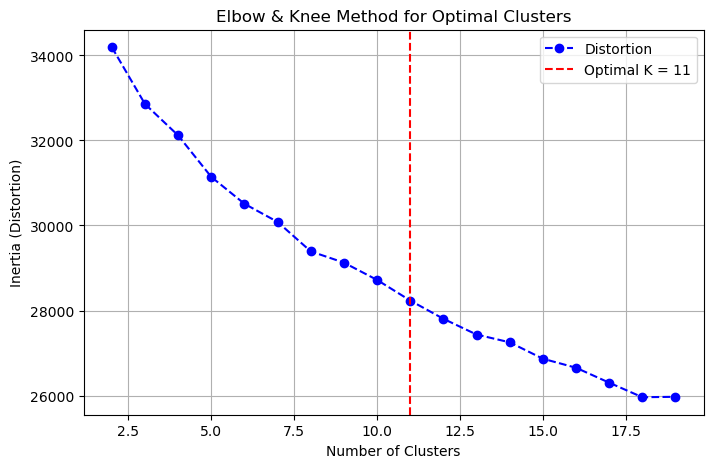

In [21]:
# Determine optimal number of clusters using the Elbow & Knee Method
distortions = []
K_range = range(2, 20)  # Test between 2 and 20 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_features)
    distortions.append(kmeans.inertia_)

# Find the optimal k using the Knee Method
knee_locator = KneeLocator(K_range, distortions, curve="convex", direction="decreasing")
optimal_clusters = knee_locator.knee
print(f"Optimal number of clusters from Knee Method: {optimal_clusters}")

# Plot the elbow & knee method
plt.figure(figsize=(8, 5))
plt.plot(K_range, distortions, marker='o', linestyle='--', color='b', label="Distortion")
plt.axvline(x=optimal_clusters, color='r', linestyle='--', label=f"Optimal K = {optimal_clusters}")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (Distortion)")
plt.title("Elbow & Knee Method for Optimal Clusters")
plt.legend()
plt.grid()
plt.show()

In [22]:
# Apply K-Means with optimal clusters
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
df["game_cluster"] = kmeans.fit_predict(pca_features)

C:\Users\Aitor\AppData\Local\Temp\ipykernel_21628\897827348.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["game_cluster"] = kmeans.fit_predict(pca_features)


In [23]:
# Silhouette score (-1 to 1)
silhouette_avg = silhouette_score(pca_features, df["game_cluster"])
print(f"Silhouette Score: {silhouette_avg:.2f}")

Silhouette Score: 0.08


In [24]:
df = pd.concat([df, cat_pca_df, mech_pca_df], axis=1)
print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'minage', 'averageweight', 'rank', 'cat_abstract', 'cat_action', 'cat_adult', 'cat_adventure', 'cat_age', 'cat_agents', 'cat_american', 'cat_ancient', 'cat_and', 'cat_animals', 'cat_arabian', 'cat_aviation', 'cat_base', 'cat_based', 'cat_bluffing', 'cat_book', 'cat_building', 'cat_card', 'cat_children', 'cat_city', 'cat_civil', 'cat_civilization', 'cat_collectible', 'cat_comic', 'cat_components', 'cat_deduction', 'cat_dexterity', 'cat_dice', 'cat_economic', 'cat_educational', 'cat_electronic', 'cat_environmental', 'cat_expansion', 'cat_exploration', 'cat_fan', 'cat_fantasy', 'cat_farming', 'cat_fiction', 'cat_fighting', 'cat_flight', 'cat_for', 'cat_game', 'cat_horror', 'cat_humor', 'cat_ii', 'cat_indian', 'cat_industry', 'cat_korean', 'cat_mafia', 'cat_manufacturing', 'cat_math', 'cat_mature', 'cat_maze', 'cat_medical', 'cat_medieval', 'cat_memory', 'cat_miniatures', 'cat_modern', 'cat_movies

### 2D Visualization

To show the choosing of the 7 clusters in a visual way

In [25]:
pca_viz = PCA(n_components=2, random_state=42)
pca_2d = pca_viz.fit_transform(pca_features)

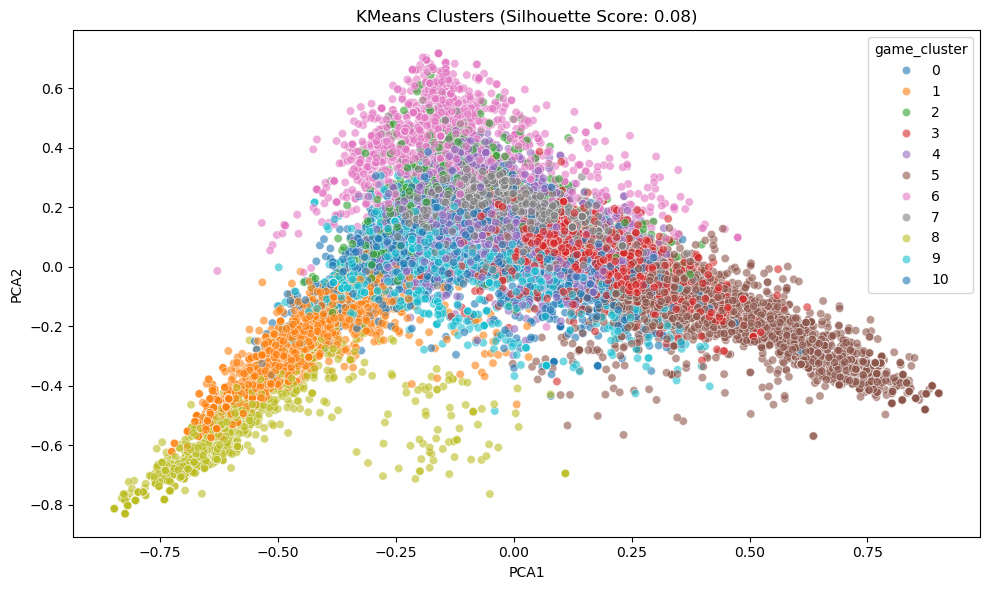

In [26]:
# Visualize clusters using PCA-reduced 2D space
plt.figure(figsize=(10,6))

sns.scatterplot(x=pca_2d[:,0],y=pca_2d[:,1],hue=df["game_cluster"],palette="tab10",alpha=0.6)

plt.title(f"KMeans Clusters (Silhouette Score: {silhouette_avg:.2f})")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()

Check some of the games that are in each cluster

In [27]:
for cluster in df["game_cluster"].unique():
    
    print("\nCLUSTER", cluster)
    
    print(
        df[df["game_cluster"] == cluster]
        .sort_values("average_rating", ascending=False)
        [["name","average_rating"]]
        .head(5)
    )


CLUSTER 4
                                              name  average_rating
14946                                  Which Side?            8.77
10414                           Breakaway Football            8.69
53      Ticket to Ride Legacy: Legends of the West            8.65
8674   Vampire: The Eternal Struggle Fifth Edition            8.63
9649                     Blood & Plunder: Rulebook            8.63

CLUSTER 10
                                                    name  average_rating
18726                     War Titans: Invaders Must Die!            9.21
13594  Clash of Spears: Rules for Skirmish Battles in...            9.13
1420   System Gateway (fan expansion for Android: Net...            9.10
414                      Arydia: The Paths We Dare Tread            9.03
12184                                             Cysmic            9.03

CLUSTER 2
                                  name  average_rating
12623               Winds of Numa Sera            8.80
9999      Doomto

Drop the now unused columns

In [28]:
tfidf_cols = [c for c in df.columns if c.startswith("cat_") or c.startswith("mech_")]
df = df.drop(columns=tfidf_cols)

print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'minage', 'averageweight', 'rank', 'log_users_rated', 'log_owned', 'log_wishing', 'playtime_mean', 'game_cluster', 'pca_cat_0', 'pca_cat_1', 'pca_cat_2', 'pca_cat_3', 'pca_cat_4', 'pca_cat_5', 'pca_cat_6', 'pca_cat_7', 'pca_cat_8', 'pca_cat_9', 'pca_cat_10', 'pca_cat_11', 'pca_cat_12', 'pca_cat_13', 'pca_cat_14', 'pca_cat_15', 'pca_cat_16', 'pca_cat_17', 'pca_cat_18', 'pca_cat_19', 'pca_cat_20', 'pca_cat_21', 'pca_cat_22', 'pca_cat_23', 'pca_cat_24', 'pca_cat_25', 'pca_cat_26', 'pca_cat_27', 'pca_cat_28', 'pca_cat_29', 'pca_cat_30', 'pca_cat_31', 'pca_cat_32', 'pca_cat_33', 'pca_cat_34', 'pca_cat_35', 'pca_cat_36', 'pca_cat_37', 'pca_cat_38', 'pca_cat_39', 'pca_cat_40', 'pca_cat_41', 'pca_cat_42', 'pca_cat_43', 'pca_cat_44', 'pca_cat_45', 'pca_cat_46', 'pca_cat_47', 'pca_cat_48', 'pca_cat_49', 'pca_cat_50', 'pca_cat_51', 'pca_mech_0', 'pca_mech_1', 'pca_mech_2', 'pca_mech_3', 'pca_mech_4', 'pc

#### Save database after feature engineering

In [29]:
df.to_csv("../data/processed/boardgames_features.csv", index=False)